In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pytest

from QAssemble.Crystal import Crystal
from QAssemble.FLatDyn import *
from QAssemble.FLatStc import *
# from QAssemble.FLocDyn import FLocDyn
from QAssemble.BLatDyn import P, W
from QAssemble.utility.Causal import CausalProjector
from QAssemble.utility.DLR import DLR


In [2]:
def _single_band_hubbard():
    crystal = Crystal(
        {
            "RVec": [[1, 0, 0], [0, 1, 0], [0, 0, 1]],
            "Basis": [[[0, 0, 0], 1]],
            "NSpin": 1,
            "NElec": 1.0,
            "KGrid": [2, 2, 2],
        }
    )
    kx, ky, kz = crystal.kpoint[:, 0], crystal.kpoint[:, 1], crystal.kpoint[:, 2]
    eps = -2.0 * (
        np.cos(2.0 * np.pi * kx)
        + np.cos(2.0 * np.pi * ky)
        + np.cos(2.0 * np.pi * kz)
    )
    hamtb = np.zeros((1, 1, 1, crystal.nk), dtype=np.complex128, order="F")
    hamtb[0, 0, 0, :] = eps
    dlr = DLR({"beta": 20.0, "cutoff": 50.0, "eps": 1.0e-12})
    return crystal, dlr, hamtb

In [3]:
# test_flocdyn_causal_projection_single_band_hubbard_average()

In [4]:
crystal, dlr, hamtb = _single_band_hubbard()

g0 = G0(crystal=crystal, dlr=dlr, hamtb=hamtb, hdf5file=None)

In [5]:
print(dlr.omega[0], dlr.omega[-1])

-56.70574739729577 26.546457922833753


In [6]:
# cutoff = dlr.omega[-1] if abs(dlr.omega[0]) < abs(dlr.omega[-1]) else abs(dlr.omega[0])
# nfreq = int((dlr.beta / np.pi * cutoff - 1) / 2)
z = dlr.MatsubaraFermionUniform() * 1j
nfreq = len(z)
g0_kf = np.zeros((1, 1, 1, crystal.nk, nfreq), dtype=np.complex128, order="F")

# for i in range(crystal.nk):
#     g0_kf[0, 0, 0, i, :] = dlr.MatsubaraDLR2Uniform(g0.kf[0, 0, 0, i, :]).reshape(len(dlr.MatsubaraFermionUniform()))

In [7]:
for i in range(crystal.nk):
    fxx = dlr.dF.dlr_from_matsubara(g0.kf[0, 0, 0, i, :], beta=dlr.beta)
    # z = dlr.MatsubaraFermionUniformFull() * 1j
    g0_kf[0, 0, 0, i, :] = dlr.dF.eval_dlr_freq(fxx[:, None, None], z, beta=dlr.beta, xi=-1)[:, 0, 0]

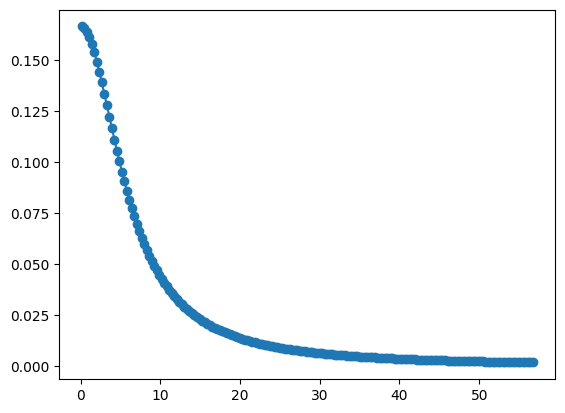

In [8]:
plt.plot(z.imag, g0_kf[0, 0, 0, 0, :].real, "o-", label="real part")
plt.show()

In [9]:
tempmat = g0_kf.copy(order="F")

high_list = []
for i in range(len(z)):
    if (abs(z[i].imag) < dlr.cutoff * 2/3):
        high_list.append(i)
print(high_list)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105]


In [10]:
len(z)
print(len(z), len(high_list))

181 106


In [11]:
norm = 1e-2
for i in high_list: 
    tempmat[..., i] += np.random.uniform(low=-norm, high=norm) + 1j * np.random.uniform(low=-norm, high=norm)

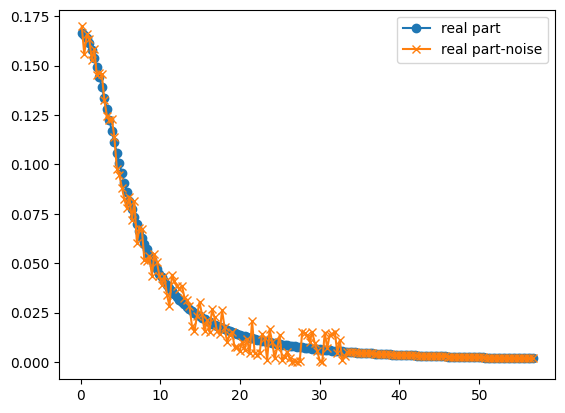

In [12]:
plt.plot(z.imag, g0_kf[0, 0, 0, 0, :].real, "o-", label="real part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, :].real, "x-", label="real part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

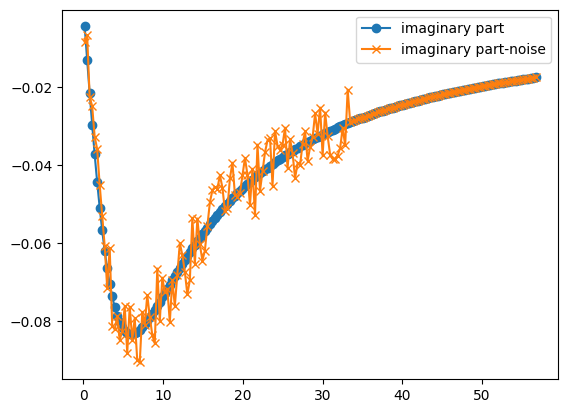

In [13]:
plt.plot(z.imag, g0_kf[0, 0, 0, 0, :].imag, "o-", label="imaginary part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, :].imag, "x-", label="imaginary part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

In [14]:
# input data carries high-frequency noise, so the causal moment/sign
# constraints cannot be met to the 1e-8 default. constraint_tol="auto" sets
# the per-channel acceptance tolerance to the data noise floor automatically
# (auto_safety * node_residual). Output is returned on the DLR grid.
proj = g0.CausalProjection(tempmat, grid="uniform", constraint_tol="auto")
proj.shape

(1, 1, 1, 8, 39)

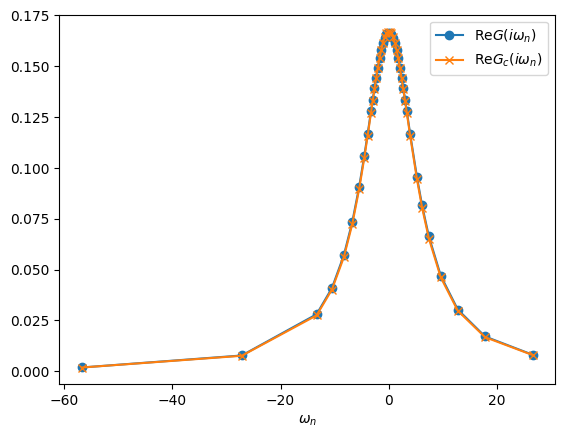

In [15]:
plt.plot(dlr.omega, g0.kf[0, 0, 0, 0, :].real, "o-", label=r"Re$G(i\omega_n)$")
plt.plot(dlr.omega, proj[0, 0, 0, 0, :].real, "x-", label=r"Re$G_{c}(i\omega_n)$")
plt.xlabel(r"$\omega_n$")

plt.legend()
plt.show()

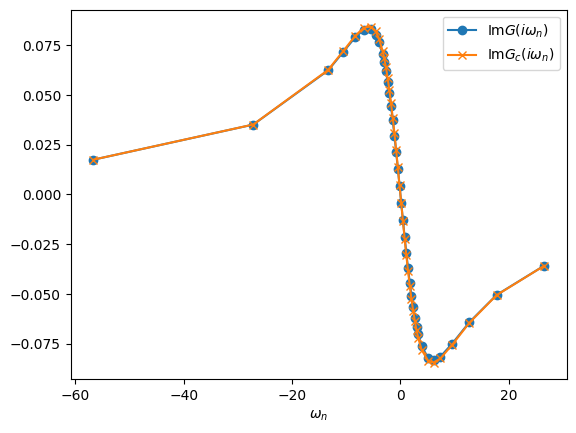

In [16]:
plt.plot(dlr.omega, g0.kf[0, 0, 0, 0, :].imag, "o-", label=r"Im$G(i\omega_n)$")
plt.plot(dlr.omega, proj[0, 0, 0, 0, :].imag, "x-", label=r"Im$G_{c}(i\omega_n)$")
plt.xlabel(r"$\omega_n$")

plt.legend()
plt.show()

In [17]:
g = G(crystal, dlr, g0.kf)

[G.CalMu0] c=0.0, gkfmu0[0,0,0,0,-1]=(0.008100287737320525-0.03583899126360426j)
[G.SearchMu] sol=0.5100814639363254, mu=0.5100814639363254, mumin=-56.70574739729577, mumax=26.546457922833753


In [18]:
g_kf = np.zeros((1, 1, 1, crystal.nk, nfreq), dtype=np.complex128, order="F")
for i in range(crystal.nk):
    fxx = dlr.dF.dlr_from_matsubara(g.kf[0, 0, 0, i, :], beta=dlr.beta)
    # z = dlr.MatsubaraFermionUniformFull() * 1j
    g_kf[0, 0, 0, i, :] = dlr.dF.eval_dlr_freq(fxx[:, None, None], z, beta=dlr.beta, xi=-1)[:, 0, 0]


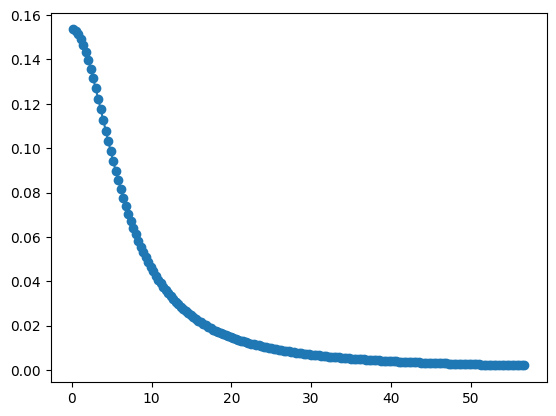

In [19]:
plt.plot(z.imag, g_kf[0, 0, 0, 0, :].real, "o-", label="real part")
plt.show()

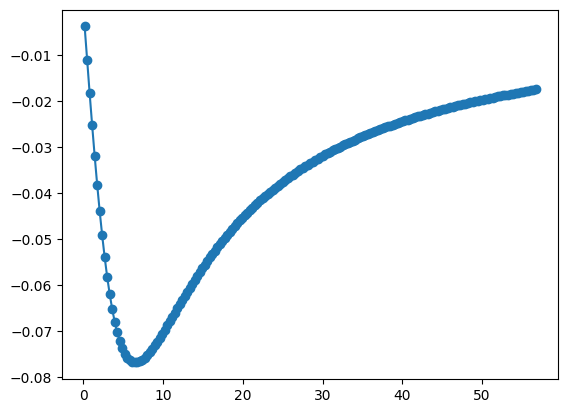

In [20]:
plt.plot(z.imag, g_kf[0, 0, 0, 0, :].imag, "o-", label="imaginary part")
plt.show()

In [21]:
tempmat = g_kf.copy(order="F")
norm = 1e-2
for i in high_list: 
    tempmat[..., i] += np.random.uniform(low=-norm, high=norm) + 1j * np.random.uniform(low=-norm, high=norm)

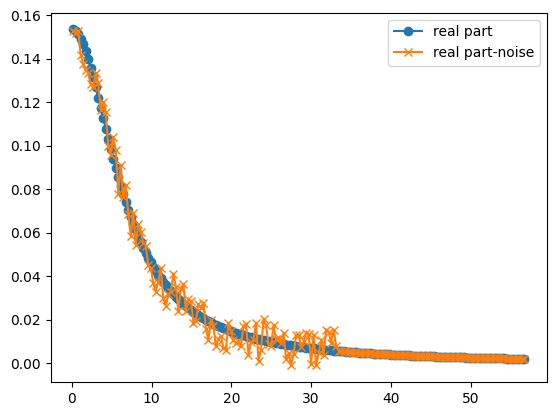

In [22]:
plt.plot(z.imag, g_kf[0, 0, 0, 0, :].real, "o-", label="real part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, :].real, "x-", label="real part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

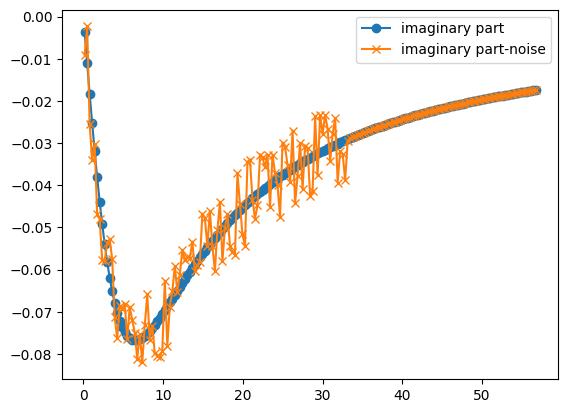

In [23]:
plt.plot(z.imag, g_kf[0, 0, 0, 0, :].imag, "o-", label="imaginary part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, :].imag, "x-", label="imaginary part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

In [24]:
proj = g.CausalProjection(tempmat, grid="uniform", constraint_tol="auto")
proj.shape

(1, 1, 1, 8, 39)

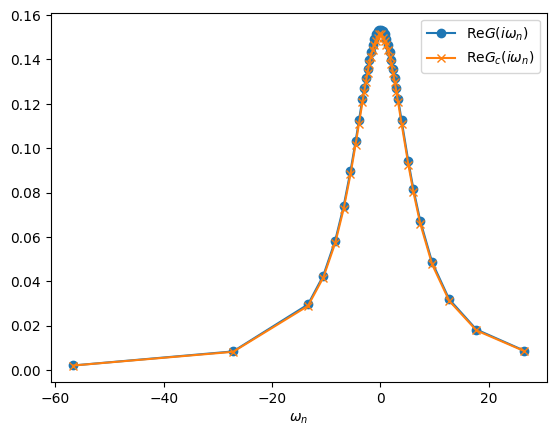

In [25]:
plt.plot(dlr.omega, g.kf[0, 0, 0, 0, :].real, "o-", label=r"Re$G(i\omega_n)$")
plt.plot(dlr.omega, proj[0, 0, 0, 0, :].real, "x-", label=r"Re$G_{c}(i\omega_n)$")
plt.xlabel(r"$\omega_n$")

plt.legend()
plt.show()

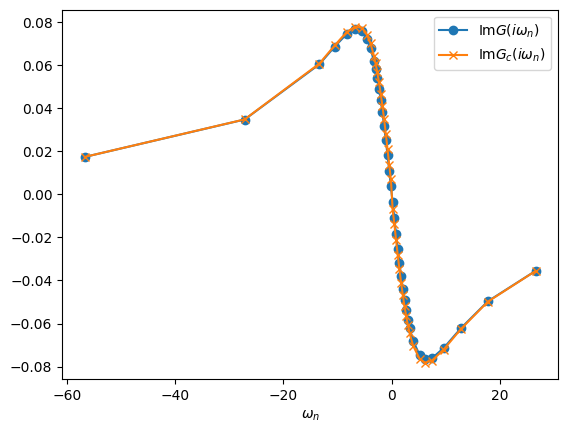

In [26]:
plt.plot(dlr.omega, g.kf[0, 0, 0, 0, :].imag, "o-", label=r"Im$G(i\omega_n)$")
plt.plot(dlr.omega, proj[0, 0, 0, 0, :].imag, "x-", label=r"Im$G_{c}(i\omega_n)$")
plt.xlabel(r"$\omega_n$")

plt.legend()
plt.show()

In [27]:
# --- BLatStc.V input for a single-band Hubbard model, U fixed to 1 ---
# V (BLatStc) is built from a crystal and a "twobody" input dict.  The raw
# input uses (atom, orbital) keys; SlaterKanamori with a 1-orbital problem
# reduces to a plain local U.  NonLocal=None keeps only the local interaction.
from QAssemble.BLatStc import V

crystal, dlr, _ = _single_band_hubbard()

twobody = {
    "Local": {
        "Parameter": "SlaterKanamori",
        "option": {
            # (atom index, orbital): single-band -> U only (J=0, l=0)
            (0, 0): {"U": 1.0, "J": 0.0, "l": 0},
        },
    },
    "NonLocal": {
        ((0, 0), (0, 0)): {
            0.2 : [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
        }
    }
}

vbare = V(crystal=crystal, twobody=twobody, hdf5file=None)
print("vloc (U):", vbare.vloc.vloc[:, :, 0, 0])
print("V(k) shape:", vbare.k.shape)
print("V(k)[0,0,0,0,:]:", vbare.k[0, 0, 0, 0, :])


vloc (U): [[1.]]
V(k) shape: (1, 1, 1, 1, 8)
V(k)[0,0,0,0,:]: [1.6+0.j 1.2+0.j 1.2+0.j 0.8+0.j 1.2+0.j 0.8+0.j 0.8+0.j 0.4+0.j]


In [28]:
sigh = SigH(crystal = crystal, occ = g.occ, vbare=vbare.k, hdf5file=None)
sigf = SigF(crystal=crystal, occr = g.occr, vbare=vbare.r, hdf5file=None)

In [29]:
p = P(crystal=crystal, dlr = dlr, green=g0.rt, hdf5file=None)

In [30]:
dlr.MatsubaraBosonUniform()

array([  0.        ,   0.31415927,   0.62831853,   0.9424778 ,
         1.25663706,   1.57079633,   1.88495559,   2.19911486,
         2.51327412,   2.82743339,   3.14159265,   3.45575192,
         3.76991118,   4.08407045,   4.39822972,   4.71238898,
         5.02654825,   5.34070751,   5.65486678,   5.96902604,
         6.28318531,   6.59734457,   6.91150384,   7.2256631 ,
         7.53982237,   7.85398163,   8.1681409 ,   8.48230016,
         8.79645943,   9.1106187 ,   9.42477796,   9.73893723,
        10.05309649,  10.36725576,  10.68141502,  10.99557429,
        11.30973355,  11.62389282,  11.93805208,  12.25221135,
        12.56637061,  12.88052988,  13.19468915,  13.50884841,
        13.82300768,  14.13716694,  14.45132621,  14.76548547,
        15.07964474,  15.393804  ,  15.70796327,  16.02212253,
        16.3362818 ,  16.65044106,  16.96460033,  17.27875959,
        17.59291886,  17.90707813,  18.22123739,  18.53539666,
        18.84955592,  19.16371519,  19.47787445,  19.79

In [31]:
p_kf = np.zeros((1, 1, 1, 1, crystal.nk, len(dlr.MatsubaraBosonUniform())), dtype=np.complex128, order="F")


In [32]:
p.kf.shape

(1, 1, 1, 1, 8, 47)

In [110]:
from scipy.linalg import lu_solve

p_kf = np.zeros((1, 1, 1, 1, crystal.nk, len(dlr.MatsubaraBosonUniform())),
                dtype=np.complex128, order="F")

for i in range(crystal.nk):
    gq = p.kf[0, 0, 0, 0, i, :]

    fxx = lu_solve((dlr.dB.dlrmf2cf, dlr.dB.mf2cfpiv), gq[:, None] / dlr.beta)
    fxx /= dlr.dB.bosonic_corr_x[:, None]

    z = dlr.MatsubaraBosonUniform() * 1j
    p_kf[0, 0, 0, 0, i, :] = dlr.dB.eval_dlr_freq(
        fxx, z, beta=dlr.beta, xi=1
    )[:, 0]

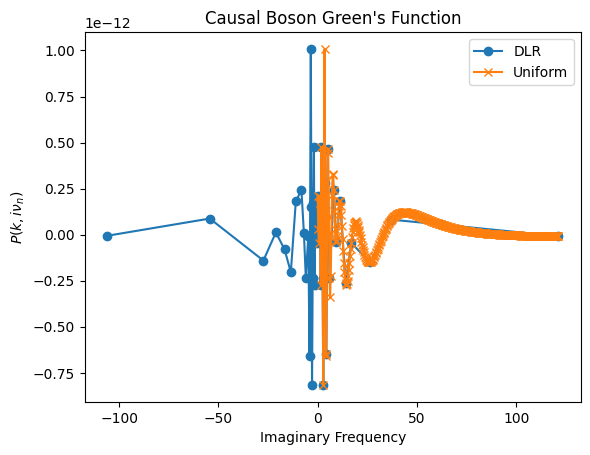

In [111]:
plt.plot(dlr.nu, p.kf[0, 0, 0, 0, 0, :].real, "o-", label="DLR")
plt.plot(z.imag, p_kf[0, 0, 0, 0, 0, :].real, "x-", label="Uniform")
plt.xlabel("Imaginary Frequency")
plt.ylabel(r"$P(k, i\nu_n)$")
plt.title("Causal Boson Green's Function")
plt.legend()
plt.show()

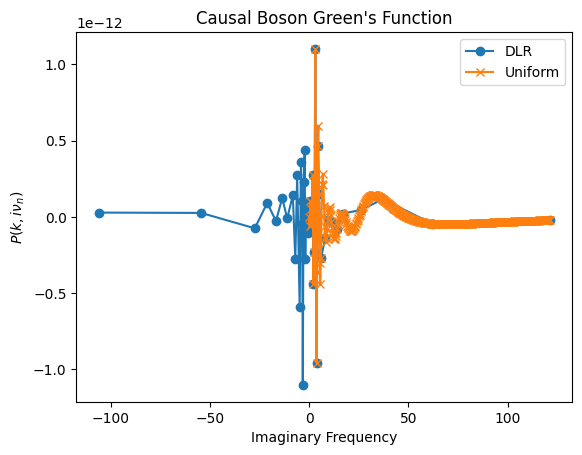

In [112]:
plt.plot(dlr.nu, p.kf[0, 0, 0, 0, 0, :].imag, "o-", label="DLR")
plt.plot(z.imag, p_kf[0, 0, 0, 0, 0, :].imag, "x-", label="Uniform")
plt.xlabel("Imaginary Frequency")
plt.ylabel(r"$P(k, i\nu_n)$")
plt.title("Causal Boson Green's Function")
plt.legend()
plt.show()

In [113]:
tempmat = p_kf.copy(order="F")

high_list = []
for i in range(len(z)):
    if (abs(z[i].imag) < dlr.cutoff * 2/3):
        high_list.append(i)
print(high_list)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106]


In [114]:
norm = 1e-4
for i in high_list: 
    tempmat[..., i] += np.random.uniform(low=-norm, high=norm) + 1j * np.random.uniform(low=-norm, high=norm)

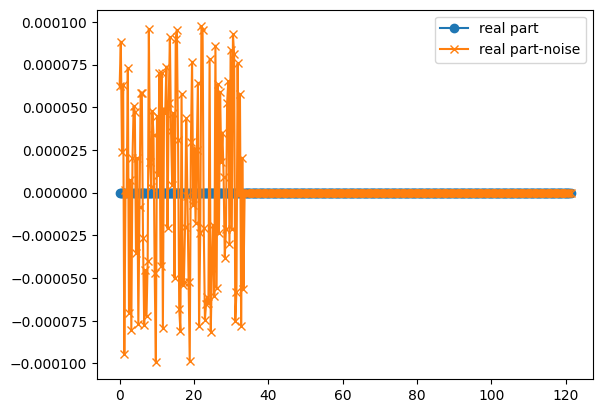

In [115]:
plt.plot(z.imag, p_kf[0, 0, 0, 0, 0, :].real, "o-", label="real part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, 0, :].real, "x-", label="real part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

In [116]:
proj = p.CausalProjection(tempmat, grid="uniform", constraint_tol="auto", coefficient_sign=1)

RuntimeError: causal QP failed for all configured solvers: clarabel:none, proxqp:none, scs:none

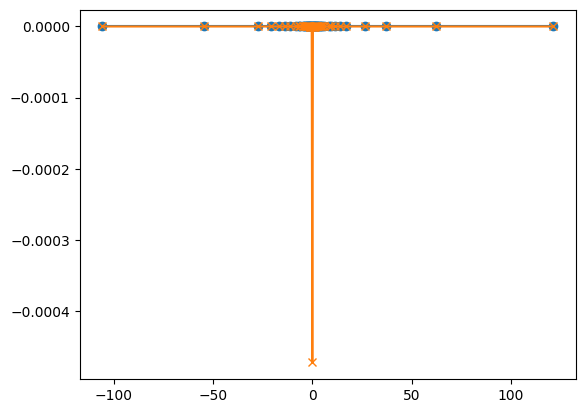

In [40]:
plt.plot(dlr.nu, p.kf[0, 0, 0, 0, 0, :].real, "o-", label="DLR")
plt.plot(dlr.nu, proj[0, 0, 0, 0, 0, :].real, "x-", label="Causal")

cond(LU square system) = 1.517e+04
cond(raw-lstsq kernel)  = 1.276e+12   (ratio 8.41e+07)
clean rel err  interp->LU: 7.2117111116681e-16
clean rel err  raw lstsq : 1.6364903540892376e-15


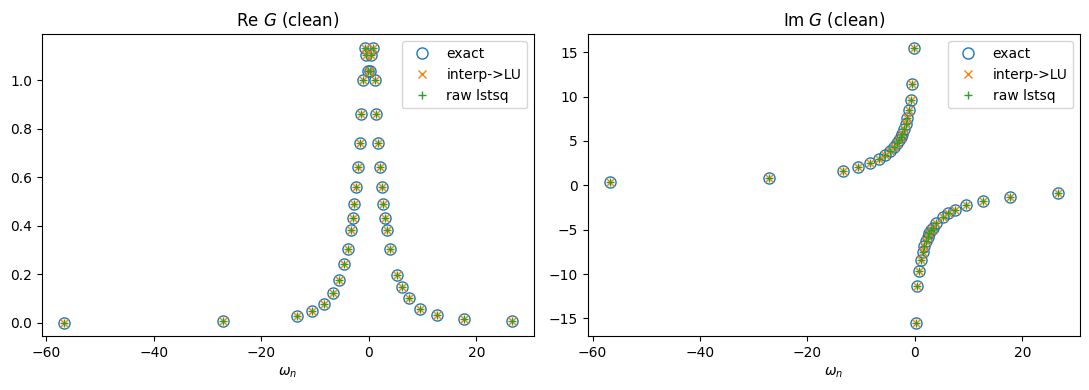

noisy rel err  interp->LU: 0.0017280574864345377
noisy rel err  raw lstsq : 0.001340798250761499


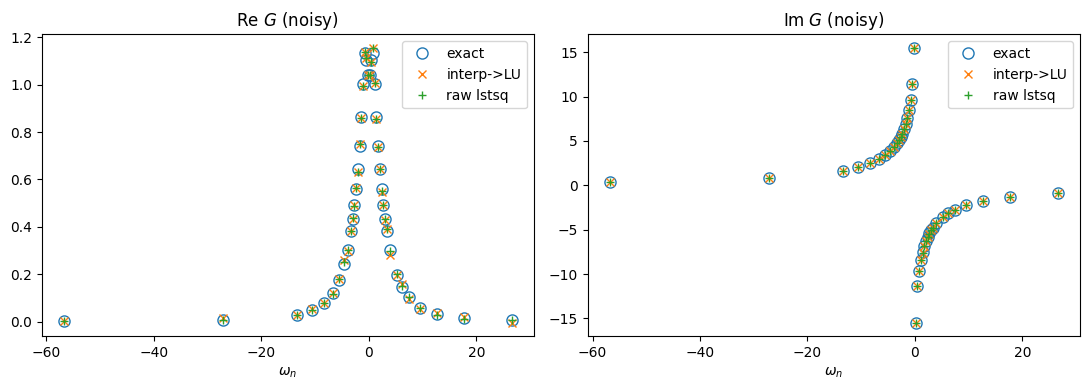

In [41]:
# --- exact vs raw-uniform lstsq vs new interp->LU: uniform -> DLR conversion ---
# MatsubaraUniform2DLR now runs a 3-step pipeline: (1) linearly interpolate the
# uniform data onto the DLR Matsubara grid, (2) solve DLR coefficients exactly
# (square LU, dlr_from_matsubara), (3) re-evaluate (matsubara_from_dlr).  This
# replaces fitting DLR coefficients DIRECTLY from the raw uniform grid in one
# global lstsq shot, which is ill-conditioned.  Compare both against the exact
# DLR-grid values for a clean and a noisy fermionic channel.
import numpy as np
import matplotlib.pyplot as plt

crystal, dlr, _ = _single_band_hubbard()

rank = len(dlr.omega)
rng = np.random.default_rng(0)
coeff = -np.abs(rng.standard_normal((rank, 1, 1)))
omega_u = dlr.MatsubaraFermionUniformFull()
exact = dlr.dF.eval_dlr_freq(coeff, 1j * dlr.omega, dlr.beta, xi=-1)[:, 0, 0]
uniform = dlr.dF.eval_dlr_freq(coeff, 1j * omega_u, dlr.beta, xi=-1)[:, 0, 0]


def raw_uniform_lstsq(data):
    """Original path: fit DLR coeffs directly from the raw uniform grid (lstsq)."""
    fxx = dlr.dF.lstsq_dlr_from_matsubara(
        w_q=omega_u * 1j, G_qaa=np.asarray(data)[:, None, None], beta=dlr.beta
    )
    return dlr.dF.matsubara_from_dlr(G_xaa=fxx, beta=dlr.beta, xi=-1)[:, 0, 0]


# conditioning: the raw-lstsq kernel is near-singular, the LU system is not
cond_lu = np.linalg.cond(dlr.dF.dlrmf2cf)
k_qx = -1.0 / (omega_u[:, None] * 1j - dlr.dF.dlrrf[None, :] / dlr.beta)
cond_lstsq = np.linalg.cond(k_qx)
print(f"cond(LU square system) = {cond_lu:.3e}")
print(f"cond(raw-lstsq kernel)  = {cond_lstsq:.3e}   (ratio {cond_lstsq/cond_lu:.2e})")

lu_clean = dlr.MatsubaraUniform2DLR(uniform, sign=-1)          # new interp->LU path
raw_clean = raw_uniform_lstsq(uniform)                         # original raw lstsq
print("clean rel err  interp->LU:", np.linalg.norm(lu_clean - exact) / np.linalg.norm(exact))
print("clean rel err  raw lstsq :", np.linalg.norm(raw_clean - exact) / np.linalg.norm(exact))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, part, lbl in ((ax[0], np.real, "Re"), (ax[1], np.imag, "Im")):
    a.plot(dlr.omega, part(exact), "o", ms=8, mfc="none", label="exact")
    a.plot(dlr.omega, part(lu_clean), "x", label="interp->LU")
    a.plot(dlr.omega, part(raw_clean), "+", label="raw lstsq")
    a.set_xlabel(r"$\omega_n$"); a.set_title(f"{lbl} $G$ (clean)"); a.legend()
fig.tight_layout(); plt.show()

# noisy channel
noise = 0.0005 * np.max(np.abs(uniform))
r = np.random.default_rng(1)
noisy = uniform + noise * (r.standard_normal(uniform.shape) + 1j * r.standard_normal(uniform.shape))
lu_n = dlr.MatsubaraUniform2DLR(noisy, sign=-1)
raw_n = raw_uniform_lstsq(noisy)
print("noisy rel err  interp->LU:", np.linalg.norm(lu_n - exact) / np.linalg.norm(exact))
print("noisy rel err  raw lstsq :", np.linalg.norm(raw_n - exact) / np.linalg.norm(exact))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, part, lbl in ((ax[0], np.real, "Re"), (ax[1], np.imag, "Im")):
    a.plot(dlr.omega, part(exact), "o", ms=8, mfc="none", label="exact")
    a.plot(dlr.omega, part(lu_n), "x", label="interp->LU")
    a.plot(dlr.omega, part(raw_n), "+", label="raw lstsq")
    a.set_xlabel(r"$\omega_n$"); a.set_title(f"{lbl} $G$ (noisy)"); a.legend()
fig.tight_layout(); plt.show()


In [42]:
w = W(crystal = crystal, dlr = dlr, pol = p.kf, vbare = vbare, hdf5file=None)

In [43]:
z = dlr.MatsubaraBosonUniform() * 1j
print(z)

[0.  +0.j         0.  +0.31415927j 0.  +0.62831853j 0.  +0.9424778j
 0.  +1.25663706j 0.  +1.57079633j 0.  +1.88495559j 0.  +2.19911486j
 0.  +2.51327412j 0.  +2.82743339j 0.  +3.14159265j 0.  +3.45575192j
 0.  +3.76991118j 0.  +4.08407045j 0.  +4.39822972j 0.  +4.71238898j
 0.  +5.02654825j 0.  +5.34070751j 0.  +5.65486678j 0.  +5.96902604j
 0.  +6.28318531j 0.  +6.59734457j 0.  +6.91150384j 0.  +7.2256631j
 0.  +7.53982237j 0.  +7.85398163j 0.  +8.1681409j  0.  +8.48230016j
 0.  +8.79645943j 0.  +9.1106187j  0.  +9.42477796j 0.  +9.73893723j
 0. +10.05309649j 0. +10.36725576j 0. +10.68141502j 0. +10.99557429j
 0. +11.30973355j 0. +11.62389282j 0. +11.93805208j 0. +12.25221135j
 0. +12.56637061j 0. +12.88052988j 0. +13.19468915j 0. +13.50884841j
 0. +13.82300768j 0. +14.13716694j 0. +14.45132621j 0. +14.76548547j
 0. +15.07964474j 0. +15.393804j   0. +15.70796327j 0. +16.02212253j
 0. +16.3362818j  0. +16.65044106j 0. +16.96460033j 0. +17.27875959j
 0. +17.59291886j 0. +17.90707813j 0

In [44]:
nu_u = dlr.MatsubaraBosonUniform()

def boson_lat_dlr_to_uniform(dlr, bf6):
    out = np.empty(bf6.shape[:-1] + (len(nu_u),), dtype=np.complex128, order="F")
    for ik in range(bf6.shape[4]):
        out[:, :, :, :, ik, :] = dlr.MatsubaraDLR2UniformGrid(
            bf6[:, :, :, :, ik, :],
            sign=1,
        )
    return out

# 1. dynamic part만 uniform으로 변환
wc_uniform = boson_lat_dlr_to_uniform(dlr, w.ckf)

# 2. full W가 필요하면 static V를 uniform grid에 broadcast해서 더함
w_uniform = wc_uniform + w.vbare.k[..., np.newaxis]

w_uniform_test = boson_lat_dlr_to_uniform(dlr, w.kf)

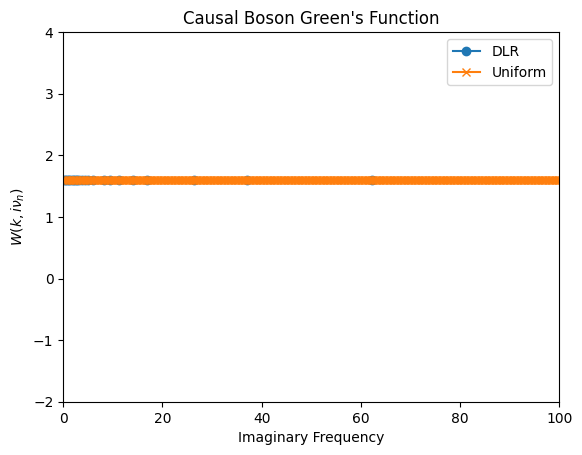

In [45]:
plt.plot(dlr.nu, w.kf[0, 0, 0, 0, 0, :].real, "o-", label="DLR")
plt.plot(z.imag, w_uniform[0, 0, 0, 0, 0, :].real, "x-", label="Uniform")

plt.xlabel("Imaginary Frequency")
plt.ylabel(r"$W(k, i\nu_n)$")
plt.title("Causal Boson Green's Function")
plt.xlim(0, 100)
plt.ylim(-2, 4)
plt.legend()
plt.show()

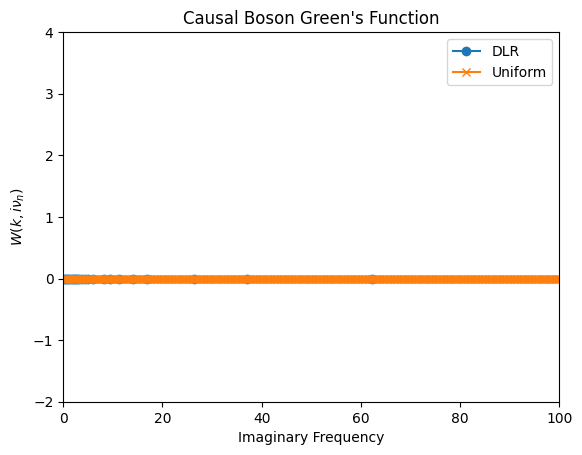

In [46]:
plt.plot(dlr.nu, w.kf[0, 0, 0, 0, 0, :].imag, "o-", label="DLR")
plt.plot(z.imag, w_uniform[0, 0, 0, 0, 0, :].imag, "x-", label="Uniform")
plt.xlabel("Imaginary Frequency")
plt.ylabel(r"$W(k, i\nu_n)$")
plt.title("Causal Boson Green's Function")
plt.xlim(0, 100)
plt.ylim(-2, 4)
plt.legend()
plt.show()

In [61]:
tempmat = w_uniform.copy(order="F")

high_list = []
for i in range(len(z)):
    if (abs(z[i].imag) < dlr.cutoff * 2/3):
        high_list.append(i)
print(high_list)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106]


In [62]:
norm = 1e-4
for i in high_list: 
    tempmat[..., i] += np.random.uniform(low=-norm, high=norm) + 1j * np.random.uniform(low=-norm, high=norm)

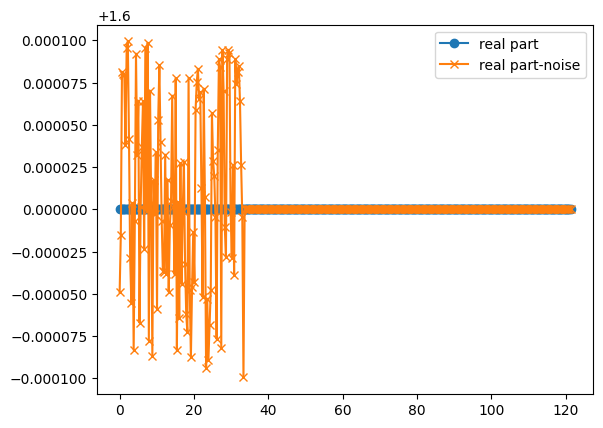

In [63]:
plt.plot(z.imag, w_uniform[0, 0, 0, 0, 0, :].real, "o-", label="real part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, 0, :].real, "x-", label="real part-noise")
plt.legend()
# plt.ylim(0.95, 1.05)
plt.show()

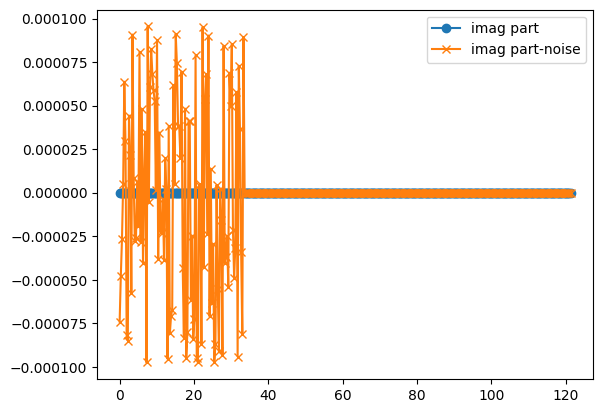

In [64]:
plt.plot(z.imag, w_uniform[0, 0, 0, 0, 0, :].imag, "o-", label="imag part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, 0, :].imag, "x-", label="imag part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

In [65]:
proj = w.CausalProjection(tempmat, grid="uniform", constraint_tol="auto")

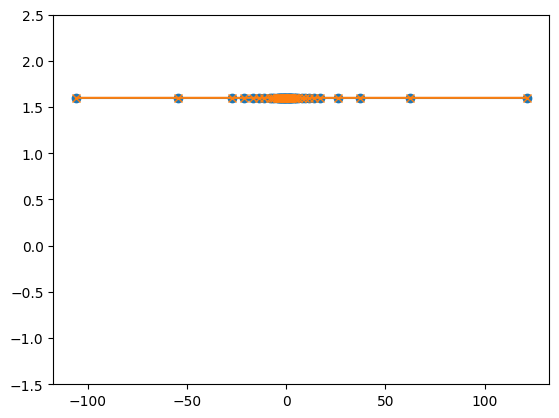

In [68]:
plt.plot(dlr.nu, w.kf[0, 0, 0, 0, 0, :].real, "o-", label="DLR")
plt.plot(dlr.nu, proj[0, 0, 0, 0, 0, :].real, "x-", label="Causal")
plt.ylim(-1.5, 2.5)
plt.show()

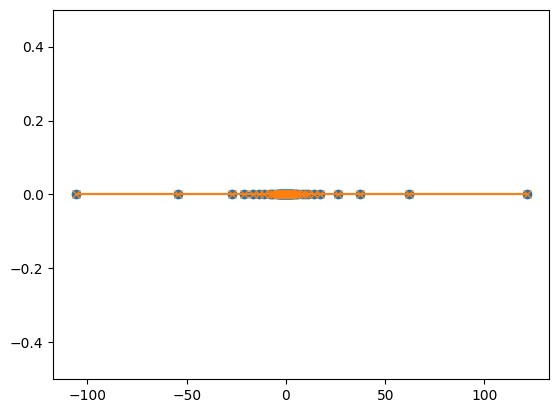

In [69]:
plt.plot(dlr.nu, w.kf[0, 0, 0, 0, 0, :].imag, "o-", label="DLR")
plt.plot(dlr.nu, proj[0, 0, 0, 0, 0, :].imag, "x-", label="Causal")
plt.ylim(-0.5, 0.5)
plt.show()

In [70]:
siggwc = SigGWC(crystal=crystal, dlr=dlr, green=g.rt, wlat = w.crt, hdf5file=None)

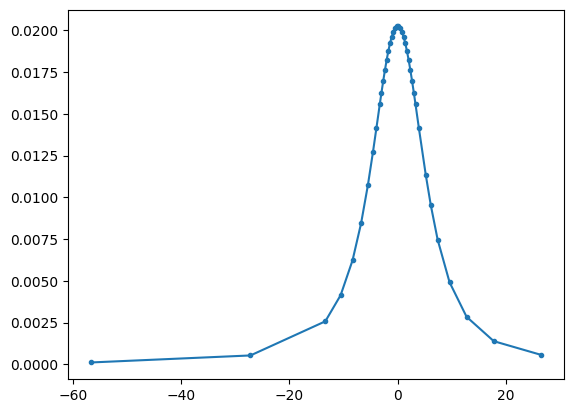

In [71]:
plt.plot(dlr.omega, siggwc.kf[0, 0, 0, 0].real, '.-')

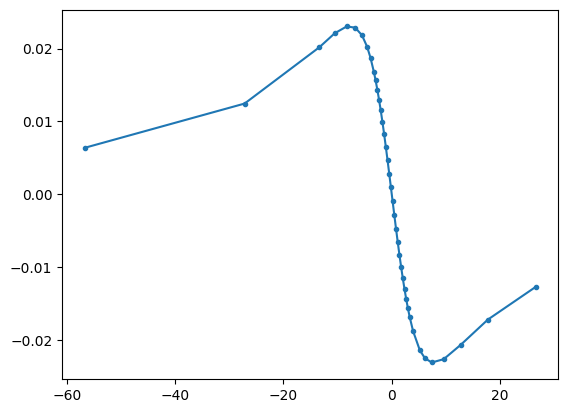

In [72]:
plt.plot(dlr.omega, siggwc.kf[0, 0, 0, 0].imag, '.-')

In [73]:
m, h = w.Moment(w_uniform, grid='uniform')

In [74]:
print(m.shape, h.shape)

(1, 1, 1, 1, 8, 3) (1, 1, 1, 1, 8)


In [75]:
np.allclose(h, vbare.k)

True

In [76]:
g2 = G(crystal, dlr, g0.kf, sigh.k, sigf.k, siggwc.kf, hdf5file=None)

[G.CalMu0] c=0.0, gkfmu0[0,0,0,0,-1]=(0.006908665674640801-0.036338320417561784j)
[G.SearchMu] sol=1.609803653800229, mu=1.609803653800229, mumin=-55.10574739729578, mumax=28.14645792283374


In [77]:
z = dlr.MatsubaraFermionUniform() * 1j
nfreq = len(z)
g_kf = np.zeros((1, 1, 1, crystal.nk, nfreq), dtype=np.complex128, order="F")
for i in range(crystal.nk):
    fxx = dlr.dF.dlr_from_matsubara(g2.kf[0, 0, 0, i, :], beta=dlr.beta)
    # z = dlr.MatsubaraFermionUniformFull() * 1j
    g_kf[0, 0, 0, i, :] = dlr.dF.eval_dlr_freq(fxx[:, None, None], z, beta=dlr.beta, xi=-1)[:, 0, 0]
tempmat = g_kf.copy(order="F")
norm = 1e-2
for i in high_list: 
    tempmat[..., i] += np.random.uniform(low=-norm, high=norm) + 1j * np.random.uniform(low=-norm, high=norm)

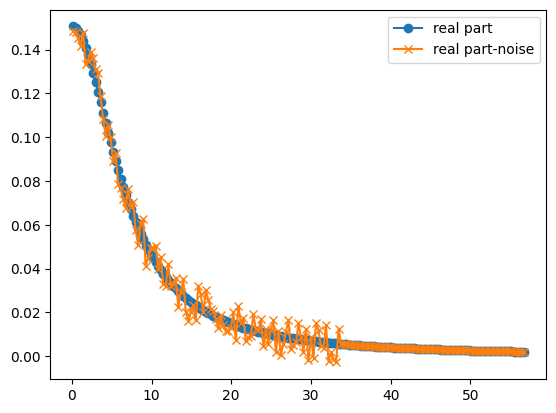

In [78]:
plt.plot(z.imag, g_kf[0, 0, 0, 0, :].real, "o-", label="real part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, :].real, "x-", label="real part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

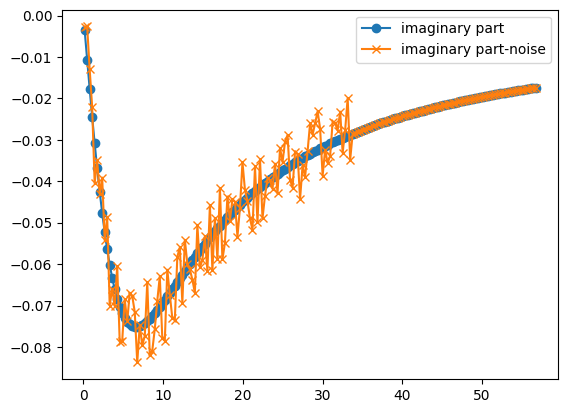

In [79]:
plt.plot(z.imag, g_kf[0, 0, 0, 0, :].imag, "o-", label="imaginary part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, :].imag, "x-", label="imaginary part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

In [80]:
proj = g2.CausalProjection(tempmat, grid="uniform", constraint_tol="auto")

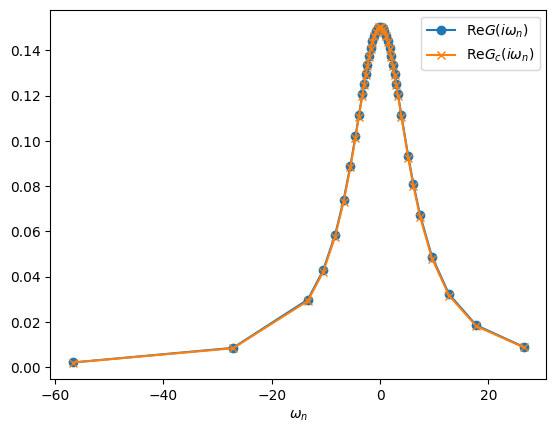

In [81]:
plt.plot(dlr.omega, g2.kf[0, 0, 0, 0, :].real, "o-", label=r"Re$G(i\omega_n)$")
plt.plot(dlr.omega, proj[0, 0, 0, 0, :].real, "x-", label=r"Re$G_{c}(i\omega_n)$")
plt.xlabel(r"$\omega_n$")

plt.legend()
plt.show()

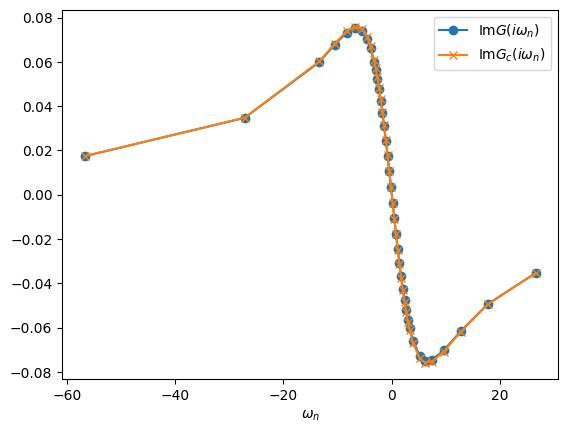

In [82]:
plt.plot(dlr.omega, g2.kf[0, 0, 0, 0, :].imag, "o-", label=r"Im$G(i\omega_n)$")
plt.plot(dlr.omega, proj[0, 0, 0, 0, :].imag, "x-", label=r"Im$G_{c}(i\omega_n)$")
plt.xlabel(r"$\omega_n$")

plt.legend()
plt.show()

In [83]:
p2 = P(crystal=crystal, dlr = dlr, green=g2.rt, hdf5file=None)

In [84]:
p_kf = np.zeros((1, 1, 1, 1, crystal.nk, len(dlr.MatsubaraBosonUniform())), dtype=np.complex128, order="F")

for i in range(crystal.nk):
    gq = p2.kf[0, 0, 0, 0, i, :]

    fxx = lu_solve((dlr.dB.dlrmf2cf, dlr.dB.mf2cfpiv), gq[:, None] / dlr.beta)
    fxx /= dlr.dB.bosonic_corr_x[:, None]

    z = dlr.MatsubaraBosonUniform() * 1j
    p_kf[0, 0, 0, 0, i, :] = dlr.dB.eval_dlr_freq(
        fxx, z, beta=dlr.beta, xi=1
    )[:, 0]

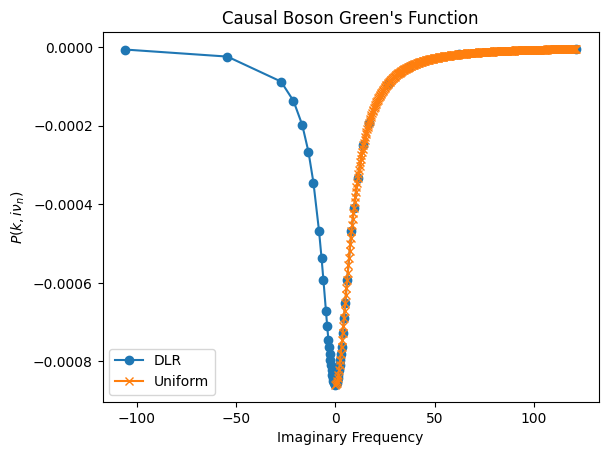

In [85]:
plt.plot(dlr.nu, p2.kf[0, 0, 0, 0, 0, :].real, "o-", label="DLR")
plt.plot(z.imag, p_kf[0, 0, 0, 0, 0, :].real, "x-", label="Uniform")
plt.xlabel("Imaginary Frequency")
plt.ylabel(r"$P(k, i\nu_n)$")
plt.title("Causal Boson Green's Function")
plt.legend()
plt.show()

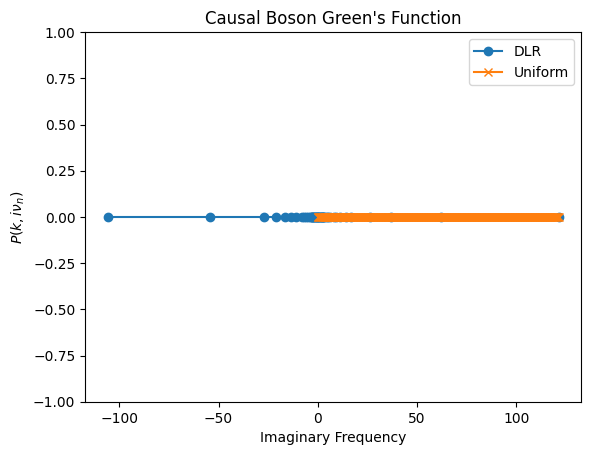

In [86]:
plt.plot(dlr.nu, p2.kf[0, 0, 0, 0, 0, :].imag, "o-", label="DLR")
plt.plot(z.imag, p_kf[0, 0, 0, 0, 0, :].imag, "x-", label="Uniform")
plt.xlabel("Imaginary Frequency")
plt.ylabel(r"$P(k, i\nu_n)$")
plt.ylim(-1,1)
plt.title("Causal Boson Green's Function")
plt.legend()
plt.show()

In [87]:
tempmat = p_kf.copy(order="F")

high_list = []
for i in range(len(z)):
    if (abs(z[i].imag) < dlr.cutoff * 2/3):
        high_list.append(i)
print(high_list)
norm = 1e-4
for i in high_list: 
    tempmat[..., i] += np.random.uniform(low=-norm, high=norm) + 1j * np.random.uniform(low=-norm, high=norm)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106]


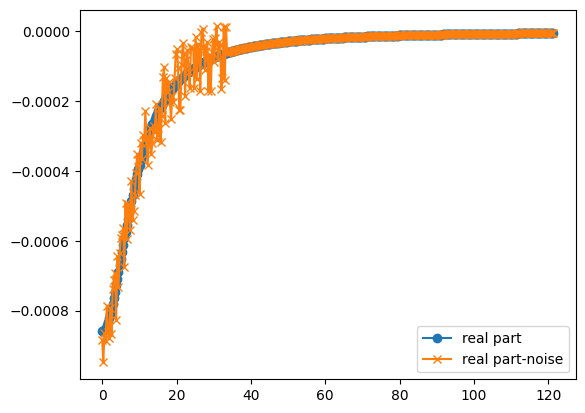

In [88]:
plt.plot(z.imag, p_kf[0, 0, 0, 0, 0, :].real, "o-", label="real part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, 0, :].real, "x-", label="real part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

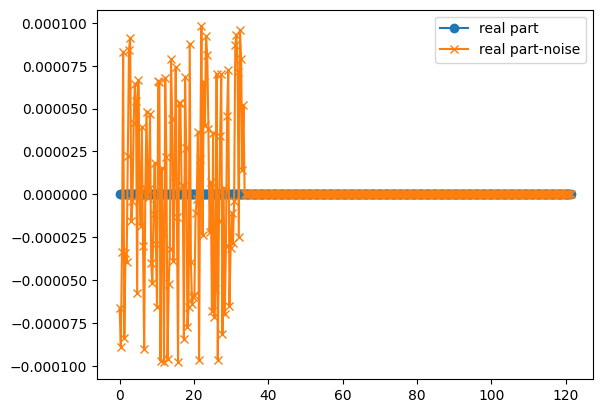

In [89]:
plt.plot(z.imag, p_kf[0, 0, 0, 0, 0, :].imag, "o-", label="real part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, 0, :].imag, "x-", label="real part-noise")
plt.legend()
# plt.xlim(40, 60)
plt.show()

In [90]:
proj = p.CausalProjection(tempmat, grid="uniform", constraint_tol="auto")

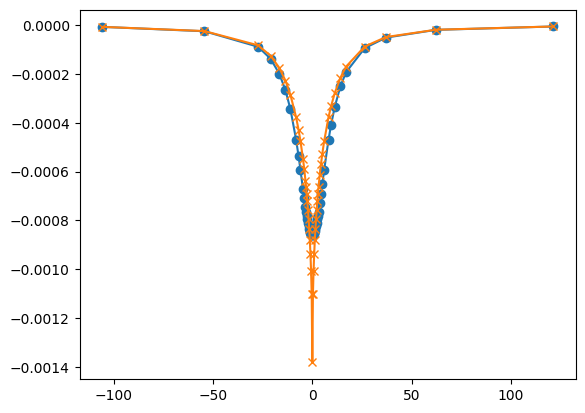

In [91]:
plt.plot(dlr.nu, p2.kf[0, 0, 0, 0, 0, :].real, "o-", label="DLR")
plt.plot(dlr.nu, proj[0, 0, 0, 0, 0, :].real, "x-", label="Causal")

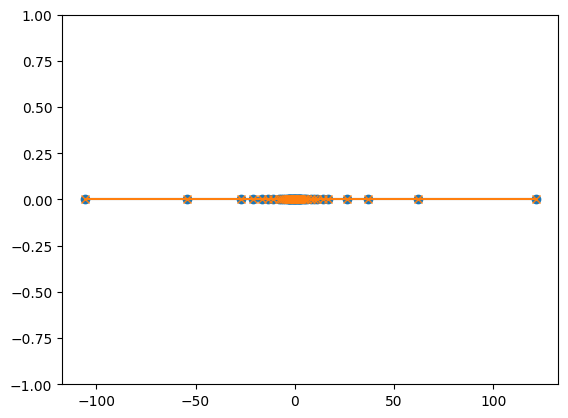

In [92]:
plt.plot(dlr.nu, p2.kf[0, 0, 0, 0, 0, :].imag, "o-", label="DLR")
plt.plot(dlr.nu, proj[0, 0, 0, 0, 0, :].imag, "x-", label="Causal")
plt.ylim(-1, 1)
plt.show()

In [93]:
w2 = W(crystal = crystal, dlr = dlr, pol = p2.kf, vbare = vbare, hdf5file=None)

In [96]:
wc_uniform = boson_lat_dlr_to_uniform(dlr, w2.ckf)

# 2. full W가 필요하면 static V를 uniform grid에 broadcast해서 더함
w_uniform = wc_uniform + w.vbare.k[..., np.newaxis]

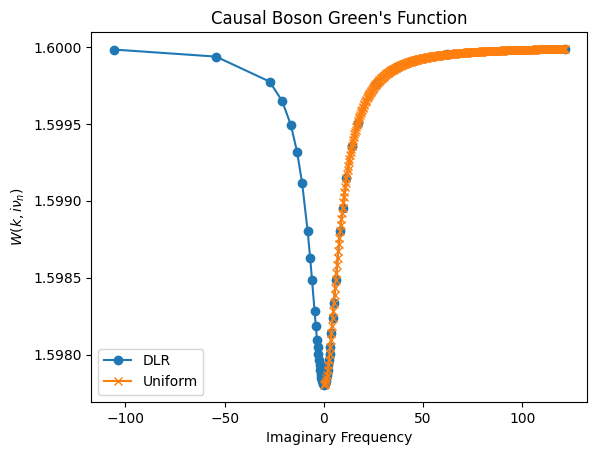

In [97]:
plt.plot(dlr.nu, w2.kf[0, 0, 0, 0, 0, :].real, "o-", label="DLR")
plt.plot(z.imag, w_uniform[0, 0, 0, 0, 0, :].real, "x-", label="Uniform")

plt.xlabel("Imaginary Frequency")
plt.ylabel(r"$W(k, i\nu_n)$")
plt.title("Causal Boson Green's Function")
# plt.xlim(0, 100)
# plt.ylim(-2, 4)
plt.legend()
plt.show()

In [100]:
tempmat = w_uniform.copy(order="F")

high_list = []
for i in range(len(z)):
    if (abs(z[i].imag) < dlr.cutoff * 2/3):
        high_list.append(i)
print(high_list)

norm = 1e-4
for i in high_list: 
    tempmat[..., i] += np.random.uniform(low=-norm, high=norm) + 1j * np.random.uniform(low=-norm, high=norm)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106]


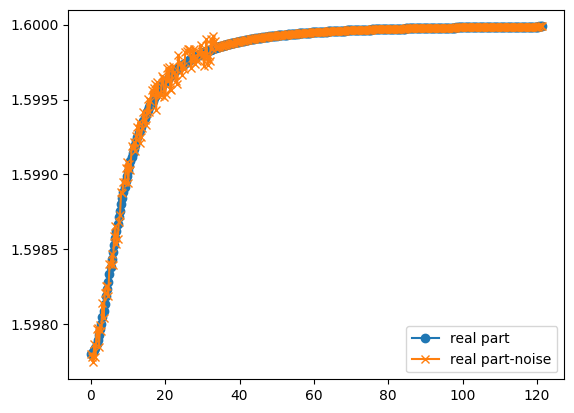

In [101]:
plt.plot(z.imag, w_uniform[0, 0, 0, 0, 0, :].real, "o-", label="real part")
plt.plot(z.imag, tempmat[0, 0, 0, 0, 0, :].real, "x-", label="real part-noise")
plt.legend()
# plt.ylim(0.95, 1.05)
plt.show()

In [103]:
proj = w.CausalProjection(tempmat, grid="uniform", constraint_tol="auto")

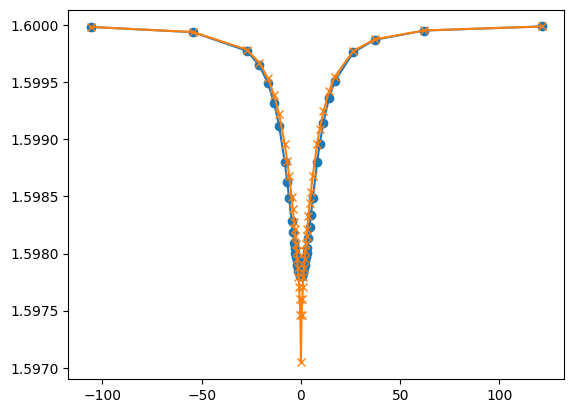

In [106]:
plt.plot(dlr.nu, w2.kf[0, 0, 0, 0, 0, :].real, "o-", label="DLR")
plt.plot(dlr.nu, proj[0, 0, 0, 0, 0, :].real, "x-", label="Causal")
plt.show()